### Convex optimizations with noise

In this notebook, we will test how the models behave on functions with noise.

In [4]:
import gymnasium as gym
import src.gymnasium_envs.non_convex_optimization_env

import src.utils.exps_utils as exps

import numpy as np

seed = 1000
in_features = 2
max_iterations = 10000

env_kwargs = {
    "amplitude" : 4,
    "frequency" : 1,
}

env_id = "non_convex_optimization_env/NonConvexOptimization-v0"

Let's test a noise-free 2D model on a noise-added problem.

In [5]:
stats = "../models/2d_convex_optimization_vec_normalize_stats.pkl"
model = "../models/2d_convex_optimization"

env_config = exps.get_env_config(seed, in_features, max_iterations, env_id, env_kwargs)
model_dir = exps.get_model_dir(stats, model)

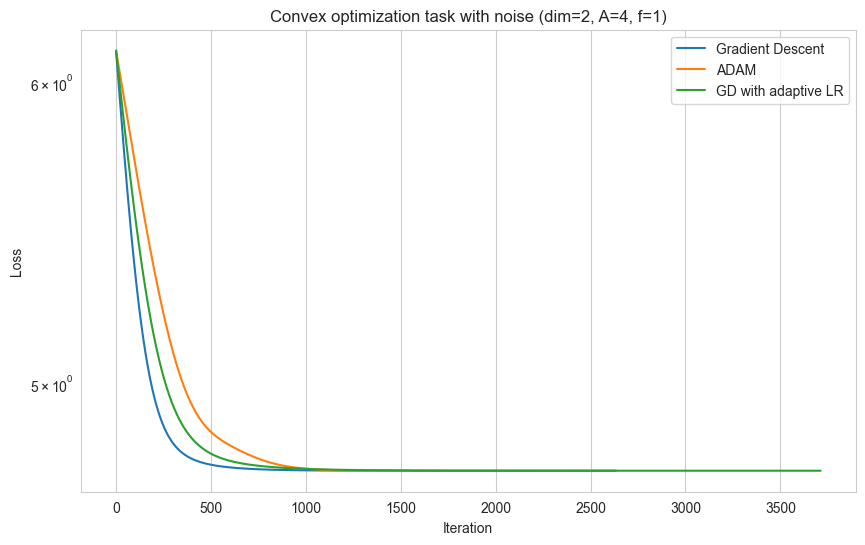

In [6]:
result = exps.optimize_exp(env_config, model_dir)

title = f"Convex optimization task with noise (dim={in_features}, A={env_kwargs["amplitude"]}, f={env_kwargs["frequency"]})"
exps.plot_converging_comparasion(result, dim=in_features, title = title)

As we can see, such a model gets stuck in local extremum.

Let's add episodes with the addition of noisy functions to the training data. This way we get a model that learns to escape local minimum.

In [7]:
env_id = "non_convex_optimization_env/NonConvexOptimization-v0"
stats = "../models/2d_noise_convex_optimization_vec_normalize_stats.pkl"
model = "../models/2d_noise_convex_optimization"

env_config = exps.get_env_config(seed, in_features, max_iterations, env_id, env_kwargs)
model_dir = exps.get_model_dir(stats, model)

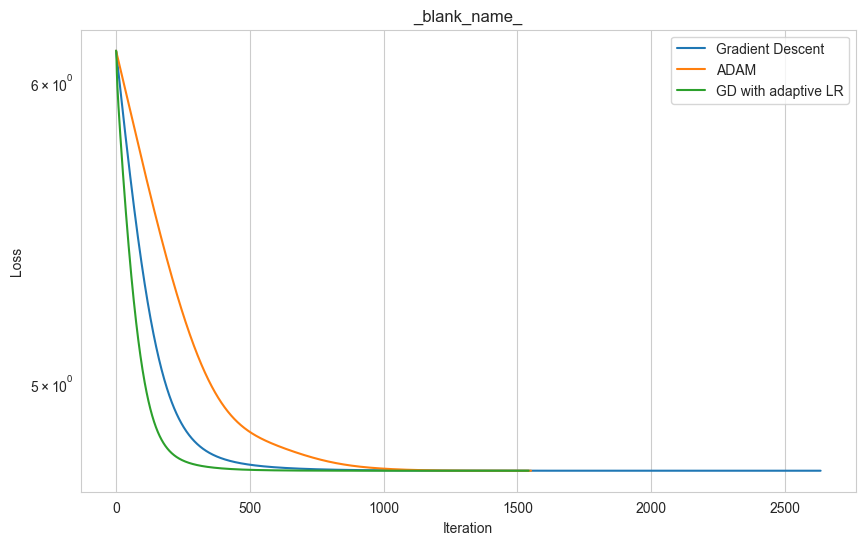

In [8]:
result = exps.optimize_exp(env_config, model_dir)

title = f"Convex optimization task with noise (dim={in_features}, A={env_kwargs["amplitude"]}, f={env_kwargs["frequency"]})"
exps.plot_converging_comparasion(result, dim=in_features)

### How convergence depends on amplitude and frequency levels

Now we are going to test model convergence with diffrent amplitude and frequency levels.

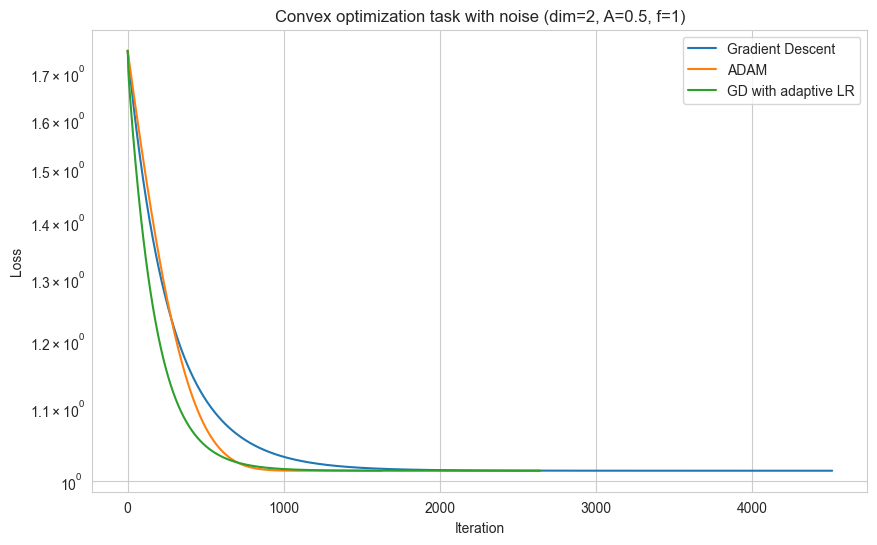

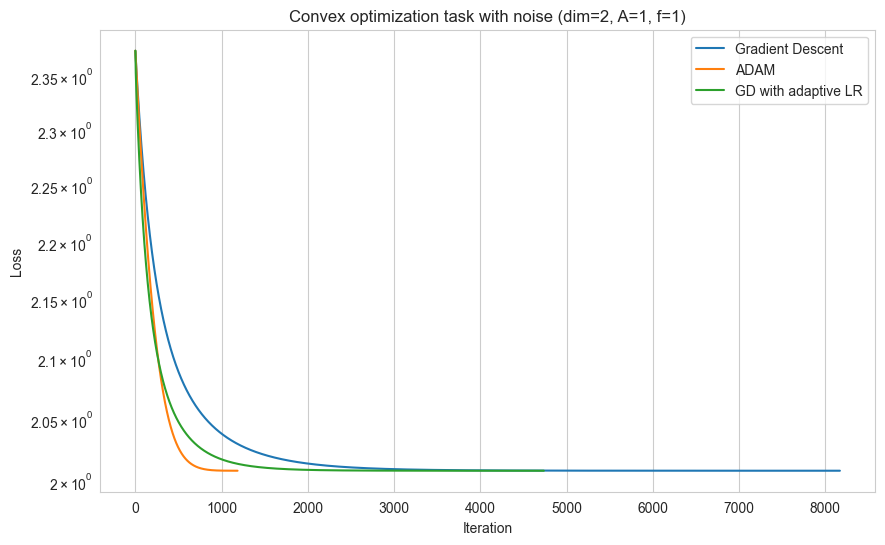

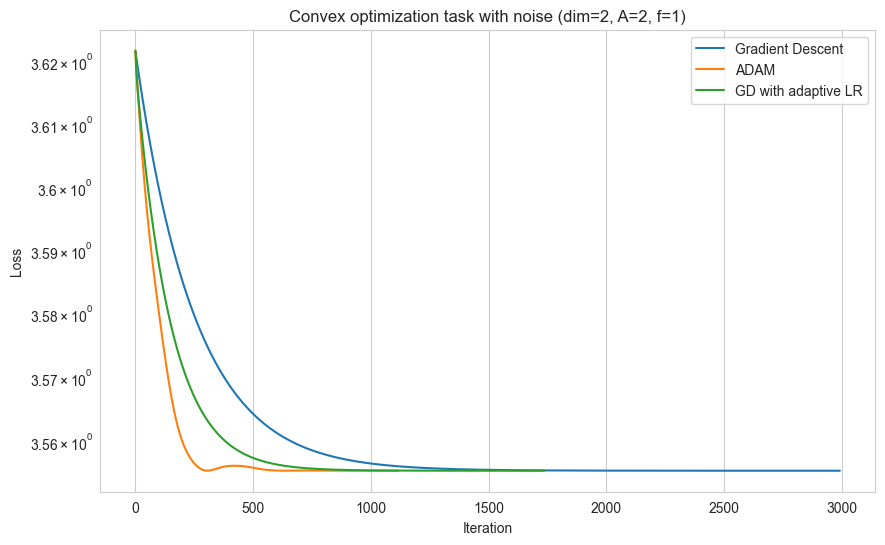

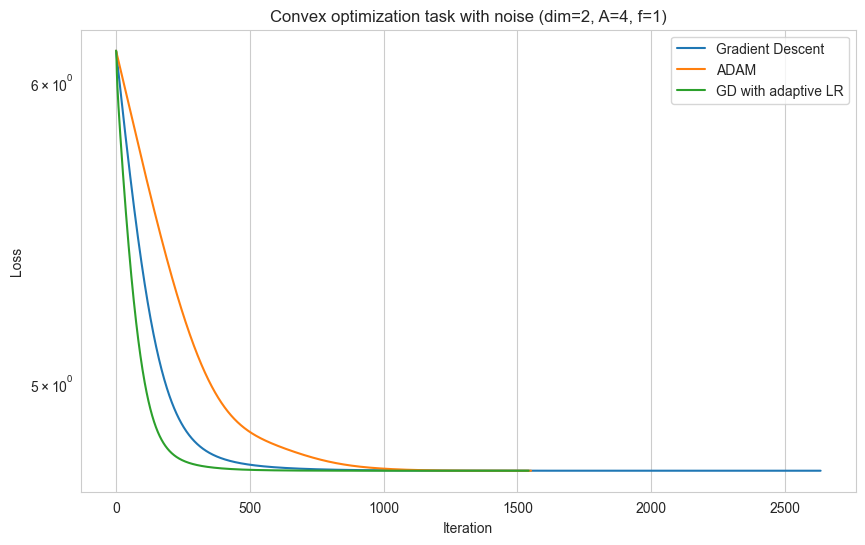

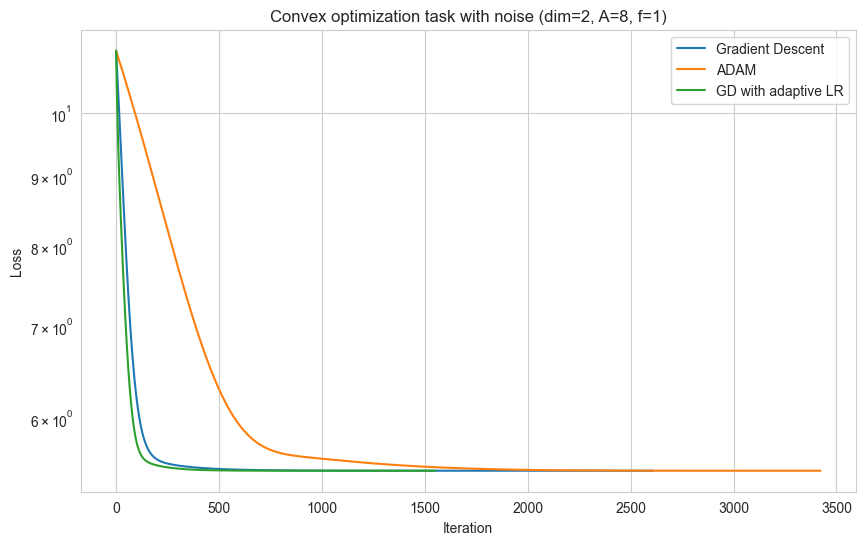

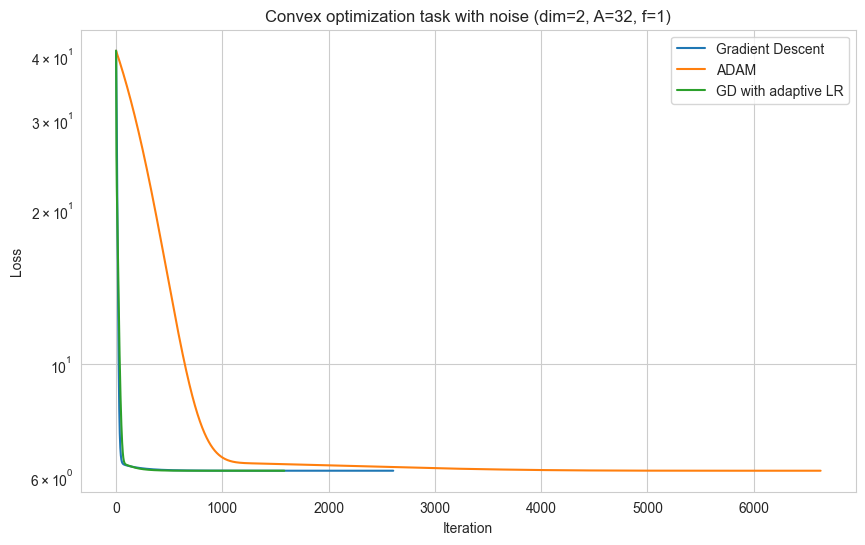

In [9]:
amplitudes = [0.5, 1, 2, 4, 8, 32]

for amplitude in amplitudes:
    env_id = "non_convex_optimization_env/NonConvexOptimization-v0"
    stats = "../models/2d_noise_convex_optimization_vec_normalize_stats.pkl"
    model = "../models/2d_noise_convex_optimization"

    env_kwargs = {
        "amplitude" : amplitude,
        "frequency" : 1,
    }

    env_config = exps.get_env_config(seed, in_features, max_iterations, env_id, env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result = exps.optimize_exp(env_config, model_dir)
    
    title = f"Convex optimization task with noise (dim={in_features}, A={env_kwargs["amplitude"]}, f={env_kwargs["frequency"]})"
    exps.plot_converging_comparasion(result, dim=in_features, title=title)

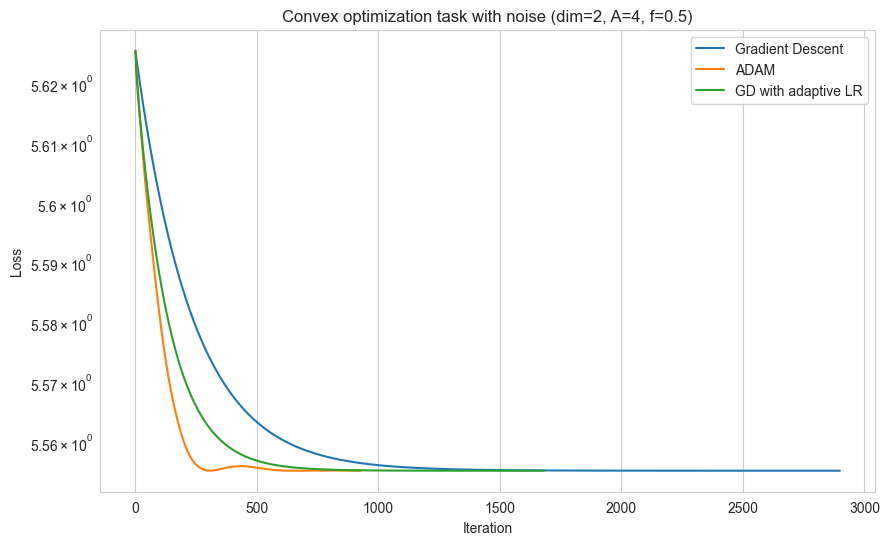

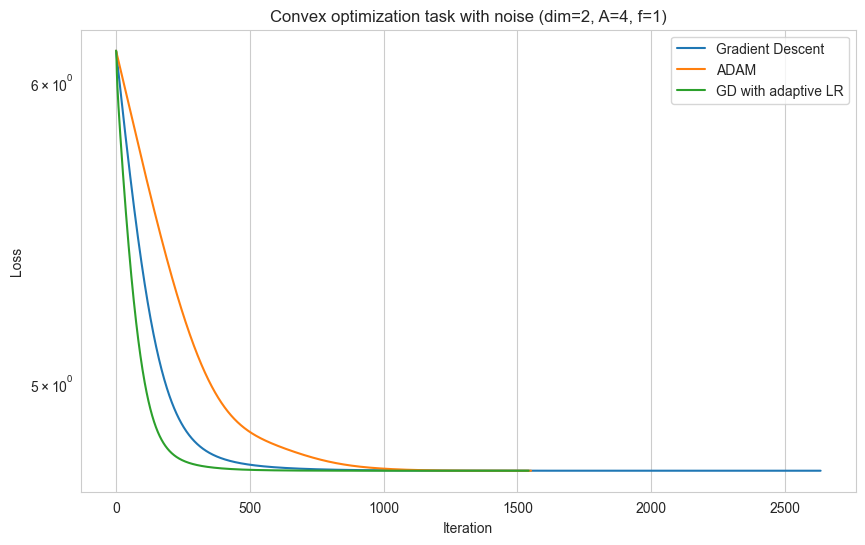

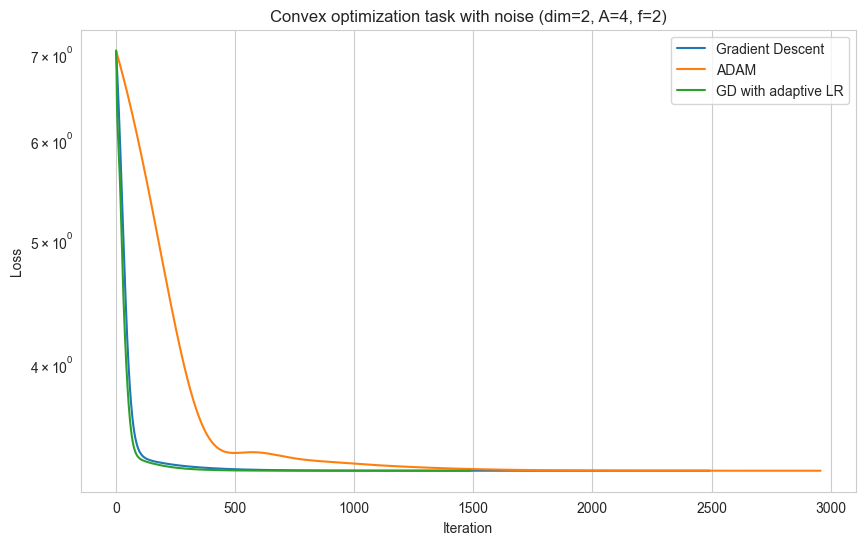

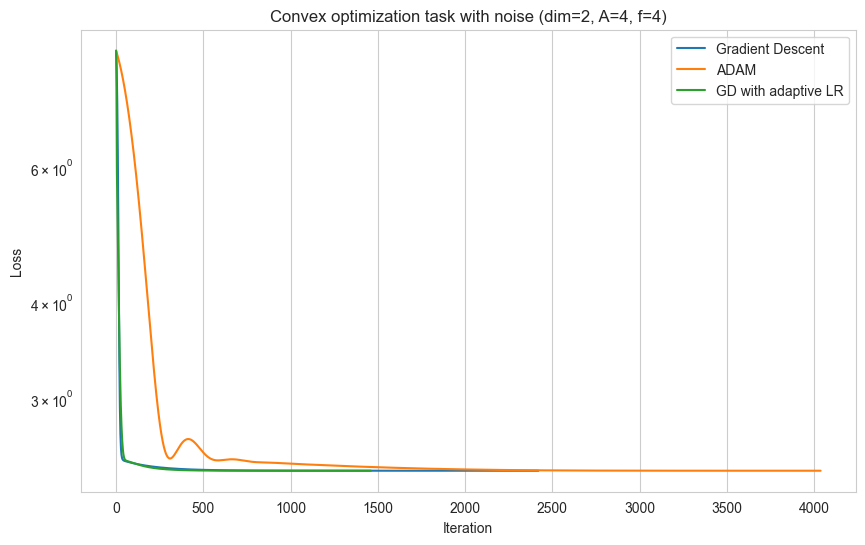

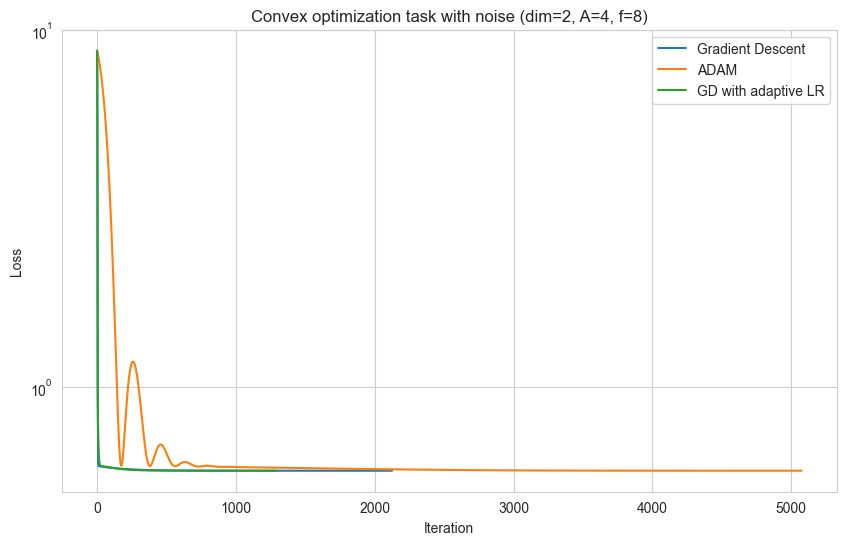

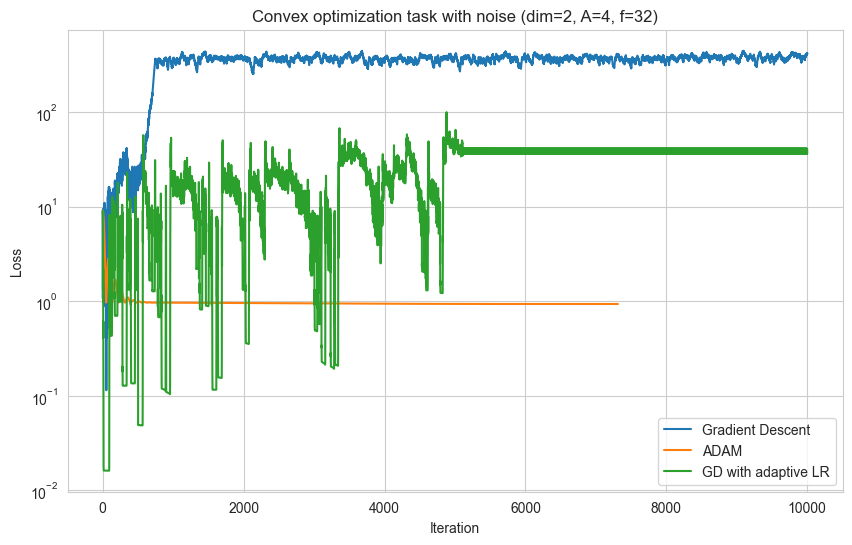

In [10]:
frequencies = [0.5, 1, 2, 4, 8, 32]

for frequency in frequencies:
    env_id = "non_convex_optimization_env/NonConvexOptimization-v0"
    stats = "../models/2d_noise_convex_optimization_vec_normalize_stats.pkl"
    model = "../models/2d_noise_convex_optimization"

    env_kwargs = {
        "amplitude" : 4,
        "frequency" : frequency,
    }

    env_config = exps.get_env_config(seed, in_features, max_iterations, env_id, env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result = exps.optimize_exp(env_config, model_dir)
    
    title = f"Convex optimization task with noise (dim={in_features}, A={env_kwargs["amplitude"]}, f={env_kwargs["frequency"]})"
    exps.plot_converging_comparasion(result, dim=in_features, title=title)

Now we want to build comparation table with diffrent noise parameters.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_amplitudes = [0.5, 1, 2, 4, 8]
_frequencies = [0.5, 1, 2, 4, 8]

amplitudes = [f'Amp {amplitude}' for amplitude in _amplitudes]
frequencies = [f'Freq {frequency}' for frequency in _frequencies]

sgd = []
adam = []
rlgd = []

for amplutude in _amplitudes:
    for frequency in _frequencies:
        env_id = "non_convex_optimization_env/NonConvexOptimization-v0"
        stats = "../models/2d_noise_convex_optimization_vec_normalize_stats.pkl"
        model = "../models/2d_noise_convex_optimization"

        env_kwargs = {
            "amplitude" : amplutude,
            "frequency" : frequency,
        }
        env_config = exps.get_env_config(seed, in_features, max_iterations, env_id, env_kwargs)
        model_dir = exps.get_model_dir(stats, model)

        result = exps.optimize_exp(env_config, model_dir)

        sgd.append((len(result['Gradient Descent'][0])) / max_iterations)
        adam.append((len(result['ADAM'][0])) / max_iterations)
        rlgd.append((len(result['GD with adaptive LR'][0])) / max_iterations)

sgd = np.array(sgd).reshape(5, 5)
adam = np.array(adam).reshape(5, 5)
rlgd = np.array(rlgd).reshape(5, 5)

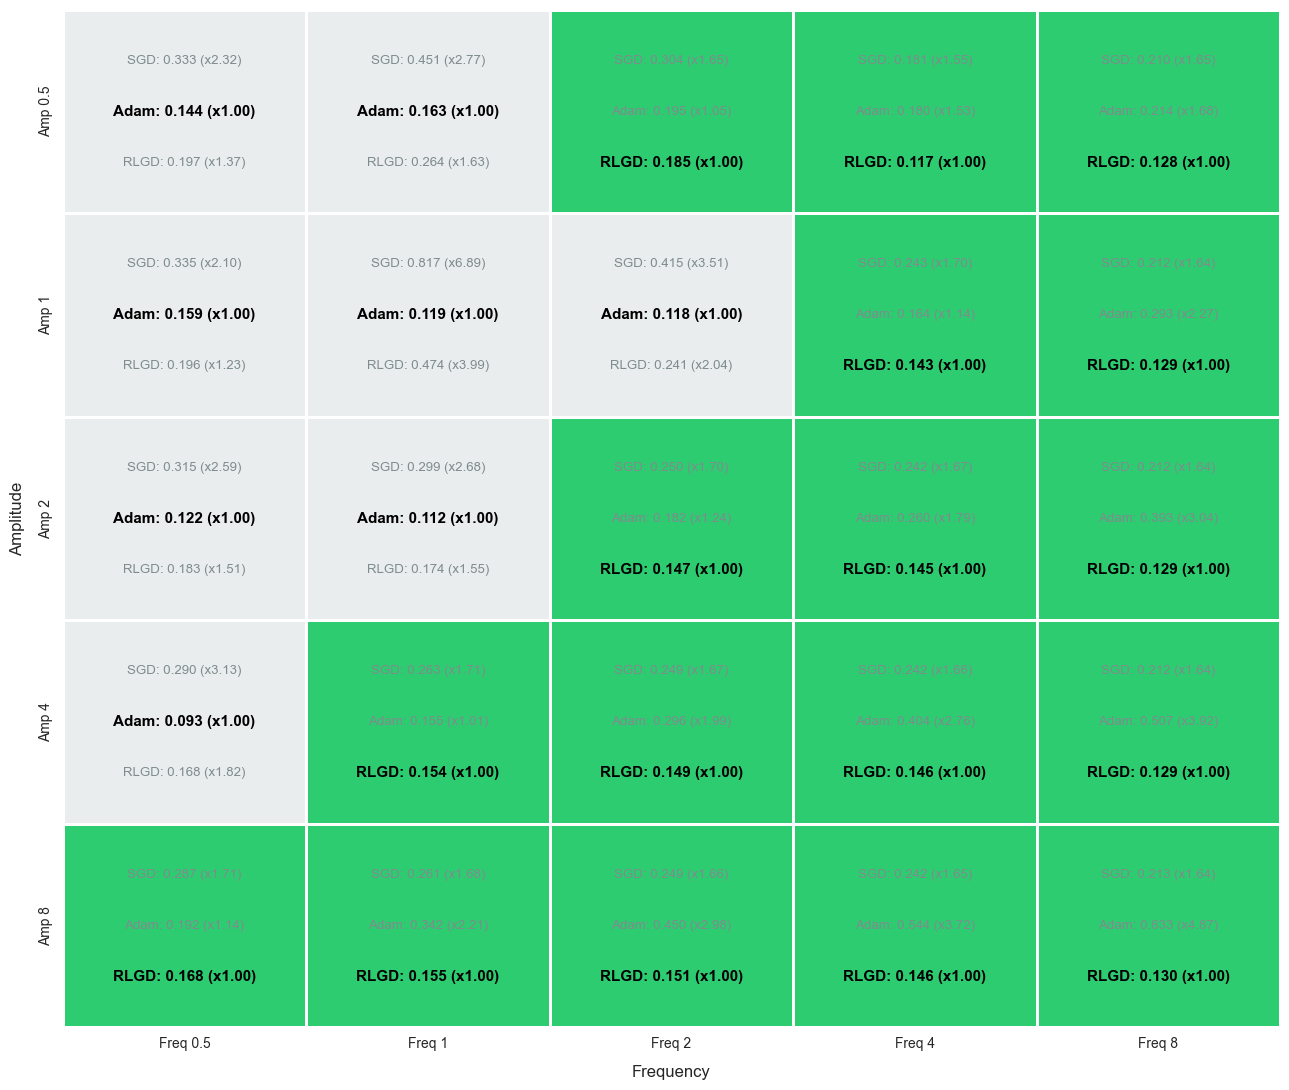

In [12]:
best_ratio = np.minimum(np.minimum(sgd, adam), rlgd)

sgd_norm = sgd / best_ratio
adam_norm = adam / best_ratio
rlgd_norm = rlgd / best_ratio

rlgd_wins = (rlgd == best_ratio).astype(int)

plt.figure(figsize=(13, 11))

sns.heatmap(
    rlgd_wins, 
    cmap=["#eaeded", "#2ecc71"], 
    cbar=False,                  
    xticklabels=frequencies, 
    yticklabels=amplitudes,
    linewidths=1, 
    linecolor='white'
)

ax = plt.gca()
for i in range(5):
    for j in range(5):
        values = [sgd[i, j], adam[i, j], rlgd[i, j]]
        winner_idx = np.argmin(values) 
        
        str_sgd  = f"SGD: {sgd[i,j]:.3f} (x{sgd_norm[i,j]:.2f})"
        str_adam = f"Adam: {adam[i,j]:.3f} (x{adam_norm[i,j]:.2f})"
        str_rlgd = f"RLGD: {rlgd[i,j]:.3f} (x{rlgd_norm[i,j]:.2f})"
        
        x = j + 0.5
        y = i + 0.5
        
        lost_style = {"color": "#7f8c8d", "fontsize": 9.5, "fontweight": "normal"}
        win_style  = {"color": "black", "fontsize": 11, "fontweight": "bold"}
        
        ax.text(x, y - 0.25, str_sgd, ha='center', va='center', 
                **(win_style if winner_idx == 0 else lost_style))
        
        ax.text(x, y, str_adam, ha='center', va='center', 
                **(win_style if winner_idx == 1 else lost_style))
        
        ax.text(x, y + 0.25, str_rlgd, ha='center', va='center', 
                **(win_style if winner_idx == 2 else lost_style))
        
plt.xlabel('Frequency', fontsize=12, labelpad=10)
plt.ylabel('Amplitude', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()